# Streaming Decoder Visualizations

This notebook visualizes results saved by `save_split_results()` / `load_split_results()`.

Each split is stored in two files:
- `{split}_metadata.parquet` — scalar + list columns (WER, glosses, predictions, segments)
- `{split}_arrays.npz` — per-frame logit arrays (logits, probs, labels, states)

**Cells are organized by visualization type:**
1. Imports & Constants
2. I/O Helpers
3. Color Palette Helpers
4. Plot 1 — Sequence Timeline
5. Plot 2 — Post-bag Confidence Heatmap
6. Plot 3 — WER Distribution
7. Plot 4 — Split Overview Grid
8. Plot 5 — Sign-level Confusion Matrix
9. Convenience — Batch Export All Sequences
10. Run Everything

---
## 1. Imports & Constants

In [1]:
from __future__ import annotations

import json
import os
from typing import Sequence

import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# Constants — must match the values used in the decoder
# ---------------------------------------------------------------------------

# Directory where the .parquet and .npz result files live
RESULTS_DIR = "./"

# Frames per second captured by the Leap Motion sensor
LEAP_FPS = 30

# Number of consecutive frames whose votes are majority-pooled before
# committing a label (the "bag" in bag-of-frames decoding)
BAG_SIZE = 5

# Minimum post-bag top-1 probability required to accept a sign prediction
CONFIDENCE_THRESHOLD = 0.35

# Minimum gap between the top-1 sign probability and the background probability;
# if the gap is smaller the frame is treated as background
SIGN_BG_MARGIN = 0.10

# Label string used for the background / no-sign class
BACKGROUND_LABEL = "background"  # change if your project uses a different name

---
## 2. I/O Helpers
Functions to load saved split results from disk and extract per-sequence arrays.

In [2]:
def load_split_results(
    split_name: str,
    results_dir: str = RESULTS_DIR,
) -> tuple[pd.DataFrame, dict]:
    """
    Load metadata DataFrame and per-frame arrays for one split.

    Reads two files written by save_split_results():
        {slug}_metadata.parquet  — WER scalars, GT glosses, predictions,
                                   emit_regions and gt_segments (as JSON strings)
        {slug}_arrays.npz        — per-frame logit/prob/label/state arrays

    Parameters
    ----------
    split_name  : e.g. "test", "dev_val", "test_(user1)" — must match
                  the slug used when saving
    results_dir : directory containing the parquet / npz files

    Returns
    -------
    df     : DataFrame with all scalars + list columns
    arrays : dict keyed by "{row_idx}__{rec_id}__{field}"
    """
    slug = (
        split_name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )
    parquet_path = os.path.join(results_dir, f"{slug}_metadata.parquet")
    npz_path     = os.path.join(results_dir, f"{slug}_arrays.npz")

    df = pd.read_parquet(parquet_path)

    def _deserialize_regions(x) -> list[tuple]:
        if not isinstance(x, str):
            return []
        out = []
        for r in json.loads(x):
            if isinstance(r, dict):
                # gt_segments saved as dicts — extract values by key
                out.append((int(r["start_frame"]), int(r["end_frame"]), str(r["label"])))
            elif isinstance(r, (list, tuple)) and len(r) >= 3:
                # emit_regions saved as lists — cast directly
                out.append((int(r[0]), int(r[1]), str(r[2])))
        return out

    for col in ["emit_regions", "gt_segments"]:
        if col in df.columns:
            df[col] = df[col].apply(_deserialize_regions)

    npz    = np.load(npz_path, allow_pickle=True)
    arrays = {k: npz[k] for k in npz.files}

    return df, arrays


def get_sequence_arrays(row: pd.Series, arrays: dict) -> dict:
    """
    Extract all per-frame arrays for a single DataFrame row.

    Constructs the key prefix from the row index and recording_id,
    then pulls every stored field from the shared arrays dict.

    Returns
    -------
    dict with keys:
        pre_bag_logits  (T, C) float32  — raw model logits before bag pooling
        post_bag_probs  (T, C) float32  — softmax probs after bag; first
                                          (BAG_SIZE-1) rows are NaN
        frame_indices   (T,)   int32    — original frame numbers
        raw_labels      (T,)   object   — per-frame pre-bag top-1 label string
        voted_labels    (T,)   object   — post-bag majority-vote label string
        raw_conf        (T,)   float32  — pre-bag top-1 confidence
        bg_conf         (T,)   float32  — post-bag background class confidence
        states          (T,)   object   — decoder FSM state string per frame
    """
    row_idx = row.name
    rec_id  = str(row["recording_id"]).replace("/", "_")
    prefix  = f"{row_idx}__{rec_id}"

    fields = [
        "pre_bag_logits", "post_bag_probs",
        "frame_indices",
        "raw_labels",     "voted_labels",
        "raw_conf",       "bg_conf",
        "states",
    ]
    return {f: arrays.get(f"{prefix}__{f}") for f in fields}


def _safe_segment_tuple(seg):
    """Convert a segment tuple/list/dict to (int start, int end, str label).
    Returns None if the input cannot be safely cast."""
    if isinstance(seg, dict):
        try:
            return (int(seg["start_frame"]), int(seg["end_frame"]), str(seg["label"]))
        except (KeyError, ValueError, TypeError):
            return None
    if isinstance(seg, (tuple, list)) and len(seg) >= 3:
        try:
            return (int(seg[0]), int(seg[1]), str(seg[2]))
        except (ValueError, TypeError):
            pass
    return None

---
## 3. Color Palette Helpers
Builds a stable color mapping from label strings to RGBA tuples. Background is always light grey; sign labels get distinct colors from the tab20 colormap.

In [3]:
def _build_label_colors(
    all_labels: Sequence[str],
    background_label: str = BACKGROUND_LABEL,
    cmap_name: str = "tab20",
) -> dict[str, tuple]:
    """
    Assign a stable, distinct color to every label.

    - Background label is always rendered as light grey so it never
      visually competes with actual sign labels.
    - Sign labels are sorted alphabetically before colors are assigned
      so the mapping is reproducible across calls with different label
      subsets (as long as the full vocabulary is the same).

    Parameters
    ----------
    all_labels       : full set of label strings seen in this context
    background_label : the label name to paint grey
    cmap_name        : matplotlib colormap to sample sign colors from

    Returns
    -------
    dict mapping label string → RGBA tuple
    """
    sign_labels = sorted(set(all_labels) - {background_label})

    # Support both old (get_cmap) and new (colormaps[]) matplotlib APIs
    try:
        cmap = plt.colormaps[cmap_name]
    except AttributeError:
        cmap = plt.cm.get_cmap(cmap_name)

    colors = [cmap(i) for i in range(len(sign_labels))] if sign_labels else []
    color_dict = {lbl: colors[i] for i, lbl in enumerate(sign_labels)}
    color_dict[background_label] = (0.88, 0.88, 0.88, 1.0)  # light grey
    return color_dict

---
## 4. Plot 1 — Sequence Timeline

**What it shows:** A three-row timeline for a single recording.

| Row | Content |
|-----|---------|
| 0 — GT regions | Colored bars spanning the ground-truth segment boundaries, labeled with the gloss |
| 1 — Pre-bag vote | Frame-by-frame color strip of the decoder's top-1 label *before* bag pooling; red dashed lines mark emission events |
| 2 — Confidence curves | Pre-bag and post-bag top-1 confidence over time, background confidence, threshold lines, and blue shading where the FSM is in the IN_SIGN state |

**Use it to:** spot where the model is uncertain, where it transitions correctly vs incorrectly, and how the bag smoothing changes confidence.

In [4]:
def plot_sequence_timeline(
    row: pd.Series,
    arrays: dict,
    label_colors: dict | None = None,
    background_label: str     = BACKGROUND_LABEL,
    figsize: tuple            = (20, 10),
    title: str | None         = None,
    save_path: str | None     = None,
) -> plt.Figure:
    """
    Five-row timeline for one sequence.

    Row 0 — Ground-truth segmentation regions (colored bars)
    Row 1 — Per-frame pre-bag top-1 label strip (raw, noisy)
    Row 2 — Per-frame post-bag voted label strip (smoothed)
    Row 3 — Pre-bag top-1 probability curve (after softmax)
    Row 4 — Pre-bag top-2 probability curve (after softmax)

    Emit regions are shown across all rows as a shaded span with
    dotted vertical lines at start and end, labelled on row 1.
    """
    seq            = get_sequence_arrays(row, arrays)
    frames         = seq["frame_indices"]
    raw_labels     = seq["raw_labels"]
    voted_labels   = seq["voted_labels"]
    pre_bag_logits = seq["pre_bag_logits"]

    # ---- Softmax → top-1 and top-2 probabilities ----------------------
    def softmax(x: np.ndarray) -> np.ndarray:
        e = np.exp(x - np.nanmax(x, axis=1, keepdims=True))
        return e / np.nansum(e, axis=1, keepdims=True)

    if pre_bag_logits is not None:
        pre_bag_probs = softmax(pre_bag_logits)
        sorted_probs  = np.sort(pre_bag_probs, axis=1)[:, ::-1]
        top1_prob     = sorted_probs[:, 0]
        top2_prob     = sorted_probs[:, 1]
    else:
        top1_prob = top2_prob = np.full(len(frames), np.nan)

    T            = frames[-1] + 1 if frames is not None and len(frames) > 0 else 1
    gt_segments  = row.get("gt_segments",  [])
    emit_regions = row.get("emit_regions", [])

    gt_segments  = [_safe_segment_tuple(s) for s in gt_segments  if _safe_segment_tuple(s)]
    emit_regions = [_safe_segment_tuple(r) for r in emit_regions if _safe_segment_tuple(r)]

    # Build color palette
    all_labels  = set(raw_labels.tolist())   if raw_labels   is not None else set()
    all_labels |= set(voted_labels.tolist()) if voted_labels is not None else set()
    all_labels |= {seg[2] for seg in gt_segments}
    all_labels.add(background_label)

    if label_colors is None:
        label_colors = _build_label_colors(all_labels, background_label)

    # ------------------------------------------------------------------
    # Figure layout: 5 rows — height ratios 1 : 1 : 1 : 2 : 2
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs  = gridspec.GridSpec(
        5, 1, figure=fig,
        height_ratios=[1, 1, 1, 2, 2],
        hspace=0.08,
    )
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])
    ax2 = fig.add_subplot(gs[2])
    ax3 = fig.add_subplot(gs[3])
    ax4 = fig.add_subplot(gs[4])

    all_axes = [ax0, ax1, ax2, ax3, ax4]

    # Shared x-tick helper — every 30 frames
    xticks      = np.arange(0, T, 30)
    xticklabels = [f"f{int(x)}" for x in xticks]

    def _apply_xticks(ax, show_labels=False):
        ax.set_xticks(xticks)
        if show_labels:
            ax.set_xticklabels(xticklabels, fontsize=7, rotation=45, ha="right")
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)
        ax.set_xlim(0, T)

    # ------------------------------------------------------------------
    # Helper — draw emit regions across a given set of axes
    # Shaded span + dotted start/end lines + label text on ax1 only
    # ------------------------------------------------------------------
    def _draw_emit_regions(axes, label_ax):
        for (start, end, label) in emit_regions:
            for ax in axes:
                # Light yellow shading for the emission span
                ax.axvspan(start, end, alpha=0.15, color="gold", zorder=0)
                # Dotted line at start
                ax.axvline(start, color="darkgreen", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
                # Dotted line at end
                ax.axvline(end, color="darkred", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
            # Label text at top of label_ax, centred on the span
            mid = (start + end) / 2
            label_ax.text(
                mid, 0.45, label,
                ha="center", va="top", fontsize=6.5, color="black",
                fontweight="bold", rotation=90, clip_on=True,
            )

    # ---- Row 0: GT segmentation regions --------------------------------
    if gt_segments:
        for (start, end, label) in gt_segments:
            color = label_colors.get(label, "steelblue")
            ax0.barh(
                0, end - start, left=start, height=0.6,
                color=color, edgecolor="black", linewidth=0.5,
            )
            cx = (start + end) / 2
            ax0.text(
                cx, 0, label,
                ha="center", va="center", fontsize=7, fontweight="bold",
                color="white" if sum(color[:3]) < 1.5 else "black",
                clip_on=True,
            )
    else:
        ax0.text(0.5, 0.5, "No GT segments available",
                 ha="center", va="center", transform=ax0.transAxes, fontsize=9)

    ax0.set_yticks([0])
    ax0.set_yticklabels(["GT"], fontsize=9)
    ax0.set_ylim(-0.5, 0.5)
    _apply_xticks(ax0, show_labels=False)
    ax0.set_title(
        title or (
            f"{row.get('user', '?')} | {row.get('recording_id', '?')} | "
            f"WER={float(row['wer']):.3f}  "
            f"GT: {row.get('ground_truth', '')}  "
            f"Pred: {row.get('prediction', '')}"
        ),
        fontsize=10, loc="left",
    )

    # ---- Row 1: pre-bag label strip ------------------------------------
    if raw_labels is not None and len(raw_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(raw_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax1.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax1.set_yticks([0])
    ax1.set_yticklabels(["Pre-bag\nvote"], fontsize=9)
    ax1.set_ylim(-0.5, 0.5)
    _apply_xticks(ax1, show_labels=False)

    # ---- Row 2: voted label strip --------------------------------------
    if voted_labels is not None and len(voted_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(voted_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax2.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax2.set_yticks([0])
    ax2.set_yticklabels(["Voted\nlabel"], fontsize=9)
    ax2.set_ylim(-0.5, 0.5)
    _apply_xticks(ax2, show_labels=False)

    # ---- Row 3: pre-bag top-1 probability ------------------------------
    ax3.plot(frames, top1_prob, color="steelblue", linewidth=1.2, zorder=3)
    ax3.axhline(CONFIDENCE_THRESHOLD, color="red", linewidth=1.0,
                linestyle=":", label=f"Threshold ({CONFIDENCE_THRESHOLD})", zorder=1)
    ax3.set_ylabel("Top-1 prob", fontsize=9)
    ax3.set_ylim(0, 1.05)
    ax3.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax3.legend(fontsize=8, loc="upper right")
    _apply_xticks(ax3, show_labels=False)

    # ---- Row 4: pre-bag top-2 probability ------------------------------
    ax4.plot(frames, top2_prob, color="darkorange", linewidth=1.2, zorder=3)
    ax4.set_ylabel("Top-2 prob", fontsize=9)
    ax4.set_ylim(0, 1.05)
    ax4.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax4.set_xlabel("Frame index", fontsize=9)
    _apply_xticks(ax4, show_labels=True)

    # ---- Draw emit regions across all axes ----------------------------
    # Label text placed on ax1 (pre-bag strip) where there's vertical room
    _draw_emit_regions(all_axes, label_ax=ax1)

    # Shared legend for label colors
    handles = [
        mpatches.Patch(color=c, label=l)
        for l, c in label_colors.items() if l != background_label
    ]
    handles.append(mpatches.Patch(color=label_colors[background_label], label=background_label))
    # Emit region legend entries
    handles.append(mpatches.Patch(color="gold", alpha=0.4, label="Emit span"))
    handles.append(Line2D([0], [0], color="darkgreen", linewidth=1.0,
                          linestyle=":", label="Emit start"))
    handles.append(Line2D([0], [0], color="darkred",  linewidth=1.0,
                          linestyle=":", label="Emit end"))
    fig.legend(
        handles=handles, loc="lower center", fontsize=7,
        ncol=min(len(handles), 8), bbox_to_anchor=(0.5, -0.02),
    )

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    else:
        plt.show()

    return fig

---
## 6. Plot 3 — WER Distribution

**What it shows:** A two-panel summary of Word Error Rate across a whole split.

| Panel | Content |
|-------|---------|
| Left — Histogram | Distribution of WER values; mean (red) and median (orange) dashed lines; std annotated |
| Right — Box plot | Per-user WER spread (or per-sequence scatter if only one user) |

**Use it to:** quickly identify whether errors are concentrated in specific users or spread uniformly, and benchmark overall decoder quality.

In [5]:
def plot_wer_distribution(
    df: pd.DataFrame,
    split_name: str       = "",
    figsize: tuple        = (14, 5),
    top_n_worst: int      = 10,
    save_path: str | None = None,
) -> plt.Figure:
    """
    Two-panel WER distribution plot for an entire split.

    Left  — Histogram of WER values with mean / median reference lines
             and sample-count + std annotation.
    Right — Per-user box plot (one box per unique user).
             If only one user is present, falls back to a per-sequence
             scatter plot so the panel is never empty.

    Also prints the top_n_worst sequences ranked by WER (descending).

    Parameters
    ----------
    df          : DataFrame returned by load_split_results()
    split_name  : shown in the figure suptitle
    top_n_worst : how many worst-WER sequences to print (default 10)
    save_path   : if given, saves figure here instead of displaying inline

    Note on double-display
    ----------------------
    plt.show() is intentionally NOT called here. Jupyter auto-renders the
    returned Figure object, so calling plt.show() would cause it to appear
    twice. When save_path is set, plt.close() is called to free memory.
    """
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    fig.suptitle(f"WER Distribution — {split_name}", fontsize=12)

    wer = df["wer"].dropna().values

    # ---- Left: WER histogram ------------------------------------------
    ax_hist.hist(wer, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
    ax_hist.axvline(wer.mean(),     color="red",    linewidth=1.5, linestyle="--",
                    label=f"Mean   {wer.mean():.3f}")
    ax_hist.axvline(np.median(wer), color="orange", linewidth=1.5, linestyle="--",
                    label=f"Median {np.median(wer):.3f}")
    ax_hist.set_xlabel("WER",   fontsize=9)
    ax_hist.set_ylabel("Count", fontsize=9)
    ax_hist.set_title("WER histogram", fontsize=10)
    ax_hist.legend(fontsize=8)
    ax_hist.set_xlim(0, max(1.0, wer.max() + 0.05))
    # Std + sample count in the top-right corner
    ax_hist.text(
        0.98, 0.97, f"n={len(wer)}\nstd={wer.std():.3f}",
        ha="right", va="top", transform=ax_hist.transAxes,
        fontsize=8, color="grey",
    )

    # ---- Right: per-user box plot (or scatter for single-user splits) --
    if "user" in df.columns and df["user"].nunique() > 1:
        users     = sorted(df["user"].unique())
        user_wers = [df.loc[df["user"] == u, "wer"].values for u in users]
        bp = ax_box.boxplot(
            user_wers, labels=users, patch_artist=True,
            medianprops=dict(color="red", linewidth=1.5),
        )
        for patch in bp["boxes"]:
            patch.set_facecolor("steelblue")
            patch.set_alpha(0.5)
        ax_box.set_xlabel("User", fontsize=9)
        ax_box.set_ylabel("WER",  fontsize=9)
        ax_box.set_title("WER by user", fontsize=10)
        ax_box.tick_params(axis="x", rotation=30)
        ax_box.set_ylim(0, max(1.0, wer.max() + 0.05))
    else:
        # Single user: show per-sequence scatter instead
        ax_box.scatter(df["sample_idx"], df["wer"],
                       color="steelblue", s=25, alpha=0.7)
        ax_box.set_xlabel("Sequence index", fontsize=9)
        ax_box.set_ylabel("WER",            fontsize=9)
        ax_box.set_title("WER per sequence", fontsize=10)
        ax_box.set_ylim(0, max(1.0, wer.max() + 0.05))

    # ---- Print top-N worst sequences ----------------------------------
    # Sort by WER descending; ties keep their original DataFrame order.
    # Prints: rank, recording_id, WER, user (if present), GT, prediction.
    n_to_show = min(top_n_worst, len(df))
    worst     = df.nlargest(n_to_show, "wer")

    print(f"\n{'='*60}")
    print(f"  Top {n_to_show} worst sequences — {split_name}")
    print(f"{'='*60}")
    for rank, (_, row) in enumerate(worst.iterrows(), start=1):
        rec_id  = row.get("recording_id", "—")
        wer_val = float(row["wer"])
        gt      = row.get("ground_truth", "—")
        pred    = row.get("prediction",   "—")
        user    = f"  user={row['user']}" if "user" in row and pd.notna(row["user"]) else ""
        print(f"  #{rank:<3} WER={wer_val:.3f}{user}")
        print(f"       id  : {rec_id}")
        print(f"       GT  : {gt}")
        print(f"       pred: {pred}")
        print()
    print(f"{'='*60}\n")

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
        plt.close(fig)  # free memory; no inline display needed when saving

    # No plt.show() — Jupyter renders the returned Figure automatically.
    # Calling plt.show() here would cause the plot to appear twice.
    return fig

---
## 8. Plot 5 — Sign-level Confusion Matrix

**What it shows:** A matrix of GT signs (rows) vs predicted signs (cols), built by aligning `emit_regions` with `gt_segments`.

**Alignment strategy:**
- For each GT segment, find the emission whose midpoint falls inside it → that's the prediction.
- Unmatched GT segments → **deletions** (reported in title)
- Unmatched emissions → **insertions** (reported in title)

**Use it to:** identify which pairs of signs are systematically confused, and quantify deletion vs insertion error modes.

In [6]:
def plot_confusion_from_emissions(
    df: pd.DataFrame,
    background_label: str = BACKGROUND_LABEL,
    figsize: tuple        = (12, 10),
    normalize: bool       = True,
    save_path: str | None = None,
) -> plt.Figure:
    """
    Sign-level confusion matrix built by aligning emit_regions with gt_segments.

    Alignment: for each GT segment, the emitted sign whose region midpoint
    falls inside the GT segment is treated as the prediction.
    Unmatched GT segments  → deletion  (tallied; shown in the title)
    Unmatched emissions    → insertion (tallied; shown in the title)

    Parameters
    ----------
    normalize : if True, each row is divided by (row_hits + row_deletions)
                so cells show per-class recall (row sums ≤ 1).
                if False, raw counts are shown.
    save_path : if given, saves figure here instead of displaying inline
    """
    # Gather every sign label that appears in predictions or GT
    all_signs = set()
    for _, row in df.iterrows():
        for seg in row.get("gt_segments", []):
            t = _safe_segment_tuple(seg)
            if t and t[2] != background_label:
                all_signs.add(t[2])
        for reg in row.get("emit_regions", []):
            t = _safe_segment_tuple(reg)
            if t and t[2] != background_label:
                all_signs.add(t[2])

    labels     = sorted(all_signs)
    label_to_i = {l: i for i, l in enumerate(labels)}
    n          = len(labels)

    if n == 0:
        print("No sign labels found in emit_regions / gt_segments.")
        return None

    # Accumulate hits, deletions, and insertions across all sequences
    conf_matrix = np.zeros((n, n), dtype=np.float32)   # [gt_i, pred_i]
    deletions   = np.zeros(n, dtype=np.float32)         # gt sign not emitted
    insertions  = 0                                     # emission with no GT match

    for _, row in df.iterrows():
        gt_segs   = [_safe_segment_tuple(s) for s in row.get("gt_segments",  []) if _safe_segment_tuple(s)]
        gt_segs   = [s for s in gt_segs   if s[2] != background_label]
        emit_regs = [_safe_segment_tuple(r) for r in row.get("emit_regions", []) if _safe_segment_tuple(r)]
        emit_regs = [r for r in emit_regs if r[2] != background_label]

        matched_emit = set()

        for (gs, ge, gl) in gt_segs:
            gt_i = label_to_i.get(gl)
            if gt_i is None:
                continue

            # Find the first emission whose midpoint is within this GT segment
            match = None
            for eidx, (es, ee, el) in enumerate(emit_regs):
                if gs <= (es + ee) / 2 <= ge:
                    match = (eidx, el)
                    break

            if match is not None:
                eidx, el = match
                pred_i   = label_to_i.get(el)
                matched_emit.add(eidx)
                if pred_i is not None:
                    conf_matrix[gt_i, pred_i] += 1
            else:
                # No emission found inside this GT segment → deletion
                deletions[gt_i] += 1

        # Any emission not matched to a GT segment → insertion
        insertions += sum(1 for eidx in range(len(emit_regs)) if eidx not in matched_emit)

    # Optionally normalise each row to give per-class recall
    if normalize:
        row_sums    = conf_matrix.sum(axis=1, keepdims=True) + deletions[:, np.newaxis]
        row_sums    = np.where(row_sums == 0, 1, row_sums)   # avoid div-by-zero
        plot_matrix = conf_matrix / row_sums
    else:
        plot_matrix = conf_matrix

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    im = ax.imshow(plot_matrix, cmap="Blues",
                   vmin=0, vmax=1 if normalize else None)

    # Annotate each cell with value (skip zeros to reduce clutter)
    thresh = plot_matrix.max() / 2.0
    for i in range(n):
        for j in range(n):
            val = plot_matrix[i, j]
            if val > 0:
                ax.text(
                    j, i,
                    f"{val:.2f}" if normalize else f"{int(val)}",
                    ha="center", va="center", fontsize=7,
                    color="white" if val > thresh else "black",
                )

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Predicted label",    fontsize=9)
    ax.set_ylabel("Ground truth label", fontsize=9)
    ax.set_title(
        f"Sign confusion matrix ({'normalized recall' if normalize else 'counts'})\n"
        f"Total deletions: {int(deletions.sum())}  |  Total insertions: {insertions}",
        fontsize=10,
    )

    plt.colorbar(im, ax=ax, label="Recall" if normalize else "Count",
                 fraction=0.03, pad=0.02)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    else:
        plt.show()

    return fig

---
## 10. Run Everything

Edit the paths and flags below, then run this cell to execute all visualizations in one go.

In [7]:
# ============================================================
# Configuration — edit these before running
# ============================================================

def get_index(df, sequence_id: str):
	return df[test_df['recording_id'] == sequence_id].index[0]


# {class_index: label_string} — must match the mapping used during training.
# Replace with your actual vocabulary dict.
id_to_label = {
    0: "AUGUST",
    1: "BIG",
    2: "BIRD",
    3: "BOAT",
    4: "COME",
    5: "DRIVER",
    6: "FARMING",
    7: "FEBRUARY",
    8: "GO",
    9: "GREETINGS",
    10: "OUR",
    11: "READ",
    12: "SMALL",
    13: "TIGER",
    14: "TRAIN",
    15: "UGLY",
    16: "VAN",
    17: "WHAT",
    18: "WHICH",
    19: "WRITE",
    20: "background",
}


# Splits to load (filenames must exist in RESULTS_DIR)
TEST_SPLIT = "test_user3_20260630t195849z"
VAL_SPLIT  = "val_user3_20260630t195849z"


# ============================================================
# Load splits
# ============================================================
test_df, test_arrays = load_split_results(TEST_SPLIT)
val_df,  val_arrays  = load_split_results(VAL_SPLIT)

print(f"Test split : {len(test_df)} sequences, mean WER={test_df['wer'].mean():.3f}")
print(f"Val  split : {len(val_df)}  sequences, mean WER={val_df['wer'].mean():.3f}")

Test split : 55 sequences, mean WER=0.047
Val  split : 33  sequences, mean WER=0.008


In [8]:
test_df.iloc[0]

sample_idx                                                                1
split                                                          Test (user3)
user                                                                  user3
recording_id                                                      P3_S10_R1
num_frames                                                              750
missing_ratio                                                           0.0
gt_len                                                                    3
pred_len                                                                  3
raw_len                                                                 721
wer                                                                     0.0
stream_mode                                                  thct_net_batch
stream_delay_frames                                                       0
num_stream_predictions                                                  721
first_predic

In [9]:
test_df['wer'].mean()

0.04696969696969697

In [10]:
from pathlib import Path

def plot_sequence_timeline(
    row: pd.Series,
    arrays: dict,
    csv_path: str | Path | None = None,
    label_colors: dict | None = None,
    background_label: str     = "background",
    figsize: tuple            = (20, 11),
    title: str | None         = None,
    save_path: str | None     = None,
) -> plt.Figure:
    """
    [ignoring loop detection]
    Six-row timeline for one sequence.

    Row 0 - Ground-truth segmentation regions (colored bars)
    Row 1 - Missing frames (red blocks where both hands are lost)
    Row 2 - Per-frame pre-bag top-1 label strip (raw, noisy)
    Row 3 - Per-frame post-bag voted label strip (smoothed)
    Row 4 - Pre-bag top-1 probability curve (after softmax)
    Row 5 - Pre-bag top-2 probability curve (after softmax)

    Emit regions are shown across all rows as a shaded span with
    dotted vertical lines at start and end.
    """
    seq            = get_sequence_arrays(row, arrays)
    frames         = seq["frame_indices"]
    raw_labels     = seq["raw_labels"]
    voted_labels   = seq["voted_labels"]
    pre_bag_logits = seq["pre_bag_logits"]

    # ---- Softmax -> top-1 and top-2 probabilities ----------------------
    def softmax(x: np.ndarray) -> np.ndarray:
        e = np.exp(x - np.nanmax(x, axis=1, keepdims=True))
        return e / np.nansum(e, axis=1, keepdims=True)

    if pre_bag_logits is not None:
        pre_bag_probs = softmax(pre_bag_logits)
        sorted_probs  = np.sort(pre_bag_probs, axis=1)[:, ::-1]
        top1_prob     = sorted_probs[:, 0]
        top2_prob     = sorted_probs[:, 1]
    else:
        top1_prob = top2_prob = np.full(len(frames), np.nan)

    T            = frames[-1] + 1 if frames is not None and len(frames) > 0 else 1
    gt_segments  = row.get("gt_segments",  [])
    emit_regions = row.get("emit_regions", [])

    gt_segments  = [_safe_segment_tuple(s) for s in gt_segments  if _safe_segment_tuple(s)]
    emit_regions = [_safe_segment_tuple(r) for r in emit_regions if _safe_segment_tuple(r)]

    # ---- Missing Frame Calculation -----------------------------------
    missing_mask = None
    if csv_path is not None and Path(csv_path).exists():
        df_csv = pd.read_csv(csv_path)
        left_ok = (df_csv["left_confidence"] > 0) & (df_csv["left_palm_x"] != 0)
        right_ok = (df_csv["right_confidence"] > 0) & (df_csv["right_palm_x"] != 0)
        missing_mask = ~(left_ok | right_ok)

    # Build color palette
    all_labels  = set(raw_labels.tolist())   if raw_labels   is not None else set()
    all_labels |= set(voted_labels.tolist()) if voted_labels is not None else set()
    all_labels |= {seg[2] for seg in gt_segments}
    all_labels.add(background_label)

    if label_colors is None:
        label_colors = _build_label_colors(all_labels, background_label)

    # ------------------------------------------------------------------
    # Figure layout: 6 rows - height ratios 1 : 0.4 : 1 : 1 : 2 : 2
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs  = gridspec.GridSpec(
        6, 1, figure=fig,
        height_ratios=[1, 0.4, 1, 1, 2, 2],
        hspace=0.08,
    )
    ax0 = fig.add_subplot(gs[0])
    ax_miss = fig.add_subplot(gs[1])
    ax1 = fig.add_subplot(gs[2])
    ax2 = fig.add_subplot(gs[3])
    ax3 = fig.add_subplot(gs[4])
    ax4 = fig.add_subplot(gs[5])

    all_axes = [ax0, ax_miss, ax1, ax2, ax3, ax4]

    # Shared x-tick helper - every 30 frames
    xticks      = np.arange(0, T, 30)
    xticklabels = [f"f{int(x)}" for x in xticks]

    def _apply_xticks(ax, show_labels=False):
        ax.set_xticks(xticks)
        if show_labels:
            ax.set_xticklabels(xticklabels, fontsize=7, rotation=45, ha="right")
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)
        ax.set_xlim(0, T)

    # ------------------------------------------------------------------
    # Helper - draw emit regions across a given set of axes
    # ------------------------------------------------------------------
    def _draw_emit_regions(axes, label_ax):
        for (start, end, label) in emit_regions:
            for ax in axes:
                # Light yellow shading for the emission span
                ax.axvspan(start, end, alpha=0.15, color="gold", zorder=0)
                # Dotted line at start
                ax.axvline(start, color="darkgreen", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
                # Dotted line at end
                ax.axvline(end, color="darkred", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
            # Label text at top of label_ax, centred on the span
            mid = (start + end) / 2
            label_ax.text(
                mid, 0.45, label,
                ha="center", va="top", fontsize=6.5, color="black",
                fontweight="bold", rotation=90, clip_on=True,
            )

    # ---- Row 0: GT segmentation regions --------------------------------
    if gt_segments:
        for (start, end, label) in gt_segments:
            color = label_colors.get(label, "steelblue")
            ax0.barh(
                0, end - start, left=start, height=0.6,
                color=color, edgecolor="black", linewidth=0.5,
            )
            cx = (start + end) / 2
            ax0.text(
                cx, 0, label,
                ha="center", va="center", fontsize=7, fontweight="bold",
                color="white" if sum(color[:3]) < 1.5 else "black",
                clip_on=True,
            )
    else:
        ax0.text(0.5, 0.5, "No GT segments available",
                 ha="center", va="center", transform=ax0.transAxes, fontsize=9)

    ax0.set_yticks([0])
    ax0.set_yticklabels(["GT"], fontsize=9)
    ax0.set_ylim(-0.5, 0.5)
    _apply_xticks(ax0, show_labels=False)
    ax0.set_title(
        title or (
            f"{row.get('user', '?')} | {row.get('recording_id', '?')} | "
            f"WER={float(row['wer']):.3f}  "
            f"GT: {row.get('ground_truth', '')}  "
            f"Pred: {row.get('prediction', '')}"
        ),
        fontsize=10, loc="left",
    )

    # ---- Row 1: Missing Frames -----------------------------------------
    if missing_mask is not None:
        missing_indices = np.where(missing_mask)[0]
        # Draw red lines for every missing frame
        for f_idx in missing_indices:
            ax_miss.axvline(x=f_idx, color='red', alpha=0.8, linewidth=1.5)

    ax_miss.set_yticks([0])
    ax_miss.set_yticklabels(["Missing"], fontsize=9, color="red")
    ax_miss.set_ylim(-0.5, 0.5)
    # Remove horizontal bar/grid line at y=0 to make vertical red lines pop
    ax_miss.spines['left'].set_visible(False)
    ax_miss.spines['right'].set_visible(False)
    ax_miss.spines['top'].set_visible(False)
    ax_miss.spines['bottom'].set_visible(False)
    ax_miss.tick_params(axis='y', left=False)
    _apply_xticks(ax_miss, show_labels=False)

    # ---- Row 2: pre-bag label strip ------------------------------------
    if raw_labels is not None and len(raw_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(raw_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax1.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax1.set_yticks([0])
    ax1.set_yticklabels(["Pre-bag\nvote"], fontsize=9)
    ax1.set_ylim(-0.5, 0.5)
    _apply_xticks(ax1, show_labels=False)

    # ---- Row 3: voted label strip --------------------------------------
    if voted_labels is not None and len(voted_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(voted_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax2.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax2.set_yticks([0])
    ax2.set_yticklabels(["Voted\nlabel"], fontsize=9)
    ax2.set_ylim(-0.5, 0.5)
    _apply_xticks(ax2, show_labels=False)

    # ---- Row 4: pre-bag top-1 probability ------------------------------
    # Use CONFIDENCE_THRESHOLD directly from config or pass it as an argument.
    # Assuming CONFIDENCE_THRESHOLD is defined in scope
    CONFIDENCE_THRESHOLD = 0.35 # Fallback if not defined
    try:
        from config import CONFIDENCE_THRESHOLD
    except:
        pass
        
    ax3.plot(frames, top1_prob, color="steelblue", linewidth=1.2, zorder=3)
    ax3.axhline(CONFIDENCE_THRESHOLD, color="red", linewidth=1.0,
                linestyle=":", label=f"Threshold ({CONFIDENCE_THRESHOLD})", zorder=1)
    ax3.set_ylabel("Top-1 prob", fontsize=9)
    ax3.set_ylim(0, 1.05)
    ax3.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax3.legend(fontsize=8, loc="upper right")
    _apply_xticks(ax3, show_labels=False)

    # ---- Row 5: pre-bag top-2 probability ------------------------------
    ax4.plot(frames, top2_prob, color="darkorange", linewidth=1.2, zorder=3)
    ax4.set_ylabel("Top-2 prob", fontsize=9)
    ax4.set_ylim(0, 1.05)
    ax4.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax4.set_xlabel("Frame index", fontsize=9)
    _apply_xticks(ax4, show_labels=True)

    # ---- Draw emit regions across all axes ----------------------------
    _draw_emit_regions(all_axes, label_ax=ax1)

    # Shared legend for label colors
    handles = [
        mpatches.Patch(color=c, label=l)
        for l, c in label_colors.items() if l != background_label
    ]
    handles.append(mpatches.Patch(color=label_colors[background_label], label=background_label))
    # Missing frames legend entry
    handles.append(Line2D([0], [0], color="red", linewidth=2.0, label="Missing Data"))
    
    handles.append(mpatches.Patch(color="gold", alpha=0.4, label="Emit span"))
    handles.append(Line2D([0], [0], color="darkgreen", linewidth=1.0,
                          linestyle=":", label="Emit start"))
    handles.append(Line2D([0], [0], color="darkred",  linewidth=1.0,
                          linestyle=":", label="Emit end"))
    fig.legend(
        handles=handles, loc="lower center", fontsize=7,
        ncol=min(len(handles), 8), bbox_to_anchor=(0.5, -0.02),
    )

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved -> {save_path}")
    else:
        plt.show()

    return fig


In [11]:

# from pathlib import Path

# def plot_sequence_timeline(
#     row: pd.Series,
#     arrays: dict,
#     csv_path: str | Path | None = None,
#     label_colors: dict | None = None,
#     background_label: str     = "background",
#     figsize: tuple            = (20, 11),
#     title: str | None         = None,
#     save_path: str | None     = None,
# ) -> plt.Figure:
#     """
#     [ignoring loop detection]
#     Six-row timeline for one sequence.

#     Row 0 — Ground-truth segmentation regions (colored bars)
#     Row 1 — Missing frames (red blocks grouping untracked frames)
#     Row 2 — Per-frame pre-bag top-1 label strip (raw, noisy)
#     Row 3 — Per-frame post-bag voted label strip (smoothed)
#     Row 4 — Pre-bag top-1 probability curve (after softmax)
#     Row 5 — Pre-bag top-2 probability curve (after softmax)
#     """
#     seq            = get_sequence_arrays(row, arrays)
#     frames         = seq["frame_indices"]
#     raw_labels     = seq["raw_labels"]
#     voted_labels   = seq["voted_labels"]
#     pre_bag_logits = seq["pre_bag_logits"]

#     # ---- Softmax → top-1 and top-2 probabilities ----------------------
#     def softmax(x: np.ndarray) -> np.ndarray:
#         e = np.exp(x - np.nanmax(x, axis=1, keepdims=True))
#         return e / np.nansum(e, axis=1, keepdims=True)

#     if pre_bag_logits is not None:
#         pre_bag_probs = softmax(pre_bag_logits)
#         sorted_probs  = np.sort(pre_bag_probs, axis=1)[:, ::-1]
#         top1_prob     = sorted_probs[:, 0]
#         top2_prob     = sorted_probs[:, 1]
#     else:
#         top1_prob = top2_prob = np.full(len(frames), np.nan)

#     T            = frames[-1] + 1 if frames is not None and len(frames) > 0 else 1
#     gt_segments  = row.get("gt_segments",  [])
#     emit_regions = row.get("emit_regions", [])

#     gt_segments  = [_safe_segment_tuple(s) for s in gt_segments  if _safe_segment_tuple(s)]
#     emit_regions = [_safe_segment_tuple(r) for r in emit_regions if _safe_segment_tuple(r)]

#     # ---- Missing Frame Calculation (Grouped into segments) -----------
#     missing_segments = []
#     if csv_path is not None and Path(csv_path).exists():
#         df_csv = pd.read_csv(csv_path)
#         left_ok = (df_csv["left_confidence"] > 0) & (df_csv["left_palm_x"] != 0)
#         right_ok = (df_csv["right_confidence"] > 0) & (df_csv["right_palm_x"] != 0)
#         missing_mask = ~(left_ok | right_ok).to_numpy()
        
#         in_missing = False
#         start_idx = 0
#         for i, is_miss in enumerate(missing_mask):
#             if is_miss and not in_missing:
#                 in_missing = True
#                 start_idx = i
#             elif not is_miss and in_missing:
#                 in_missing = False
#                 missing_segments.append((start_idx, i))
#         if in_missing:
#             missing_segments.append((start_idx, len(missing_mask)))

#     # Build color palette
#     all_labels  = set(raw_labels.tolist())   if raw_labels   is not None else set()
#     all_labels |= set(voted_labels.tolist()) if voted_labels is not None else set()
#     all_labels |= {seg[2] for seg in gt_segments}
#     all_labels.add(background_label)

#     if label_colors is None:
#         label_colors = _build_label_colors(all_labels, background_label)

#     # ------------------------------------------------------------------
#     # Figure layout: 6 rows — height ratios 1 : 1 : 1 : 1 : 2 : 2
#     # ------------------------------------------------------------------
#     fig = plt.figure(figsize=figsize, constrained_layout=True)
#     gs  = gridspec.GridSpec(
#         6, 1, figure=fig,
#         height_ratios=[1, 1, 1, 1, 2, 2],
#         hspace=0.08,
#     )
#     ax0 = fig.add_subplot(gs[0])  # GT
#     ax1 = fig.add_subplot(gs[1])  # Missing
#     ax2 = fig.add_subplot(gs[2])  # Pre-bag
#     ax3 = fig.add_subplot(gs[3])  # Voted
#     ax4 = fig.add_subplot(gs[4])  # Prob 1
#     ax5 = fig.add_subplot(gs[5])  # Prob 2

#     all_axes = [ax0, ax1, ax2, ax3, ax4, ax5]

#     # Shared x-tick helper — every 30 frames
#     xticks      = np.arange(0, T, 30)
#     xticklabels = [f"f{int(x)}" for x in xticks]

#     def _apply_xticks(ax, show_labels=False):
#         ax.set_xticks(xticks)
#         if show_labels:
#             ax.set_xticklabels(xticklabels, fontsize=7, rotation=45, ha="right")
#         else:
#             ax.set_xticklabels([])
#             ax.tick_params(bottom=False)
#         ax.set_xlim(0, T)

#     # ------------------------------------------------------------------
#     # Helper — draw emit regions across a given set of axes
#     # ------------------------------------------------------------------
#     def _draw_emit_regions(axes, label_ax):
#         for (start, end, label) in emit_regions:
#             for ax in axes:
#                 # Light yellow shading for the emission span
#                 ax.axvspan(start, end, alpha=0.15, color="gold", zorder=0)
#                 # Dotted line at start
#                 ax.axvline(start, color="darkgreen", linewidth=1.0,
#                            linestyle=":", alpha=0.9, zorder=2)
#                 # Dotted line at end
#                 ax.axvline(end, color="darkred", linewidth=1.0,
#                            linestyle=":", alpha=0.9, zorder=2)
#             # Label text at top of label_ax, centred on the span
#             mid = (start + end) / 2
#             label_ax.text(
#                 mid, 0.45, label,
#                 ha="center", va="top", fontsize=6.5, color="black",
#                 fontweight="bold", rotation=90, clip_on=True,
#             )

#     # ---- Row 0: GT segmentation regions --------------------------------
#     if gt_segments:
#         for (start, end, label) in gt_segments:
#             color = label_colors.get(label, "steelblue")
#             ax0.barh(
#                 0, end - start, left=start, height=0.6,
#                 color=color, edgecolor="black", linewidth=0.5,
#             )
#             cx = (start + end) / 2
#             ax0.text(
#                 cx, 0, label,
#                 ha="center", va="center", fontsize=7, fontweight="bold",
#                 color="white" if sum(color[:3]) < 1.5 else "black",
#                 clip_on=True,
#             )
#     else:
#         ax0.text(0.5, 0.5, "No GT segments available",
#                  ha="center", va="center", transform=ax0.transAxes, fontsize=9)

#     ax0.set_yticks([0])
#     ax0.set_yticklabels(["GT"], fontsize=9)
#     ax0.set_ylim(-0.5, 0.5)
#     _apply_xticks(ax0, show_labels=False)
#     ax0.set_title(
#         title or (
#             f"{row.get('user', '?')} | {row.get('recording_id', '?')} | "
#             f"WER={float(row['wer']):.3f}  "
#             f"GT: {row.get('ground_truth', '')}  "
#             f"Pred: {row.get('prediction', '')}"
#         ),
#         fontsize=10, loc="left",
#     )

#     # ---- Row 1: Missing Frames Strip -----------------------------------
#     # Base layer: light gray block indicating available data
#     ax1.barh(0, T, left=0, height=0.6, color="whitesmoke", zorder=-1)
    
#     if missing_segments:
#         for (start, end) in missing_segments:
#             ax1.barh(
#                 0, end - start, left=start, height=0.6,
#                 color="crimson", edgecolor="none", zorder=1
#             )
#             # Add text if the missing gap is wide enough to fit
#             if end - start > 15:
#                 cx = (start + end) / 2
#                 ax1.text(
#                     cx, 0, "MISSING",
#                     ha="center", va="center", fontsize=7, fontweight="bold",
#                     color="white", clip_on=True, zorder=2
#                 )
    
#     if csv_path is None or not Path(csv_path).exists():
#         ax1.text(0.5, 0.5, "CSV not provided",
#                  ha="center", va="center", transform=ax1.transAxes, fontsize=9)
                 
#     ax1.set_yticks([0])
#     ax1.set_yticklabels(["Missing\nFrames"], fontsize=9)
#     ax1.set_ylim(-0.5, 0.5)
#     _apply_xticks(ax1, show_labels=False)

#     # ---- Row 2: pre-bag label strip ------------------------------------
#     if raw_labels is not None and len(raw_labels) == len(frames):
#         for i, fi in enumerate(frames):
#             label = str(raw_labels[i])
#             color = label_colors.get(label, "lightgrey")
#             ax2.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

#     ax2.set_yticks([0])
#     ax2.set_yticklabels(["Pre-bag\nvote"], fontsize=9)
#     ax2.set_ylim(-0.5, 0.5)
#     _apply_xticks(ax2, show_labels=False)

#     # ---- Row 3: voted label strip --------------------------------------
#     if voted_labels is not None and len(voted_labels) == len(frames):
#         for i, fi in enumerate(frames):
#             label = str(voted_labels[i])
#             color = label_colors.get(label, "lightgrey")
#             ax3.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

#     ax3.set_yticks([0])
#     ax3.set_yticklabels(["Voted\nlabel"], fontsize=9)
#     ax3.set_ylim(-0.5, 0.5)
#     _apply_xticks(ax3, show_labels=False)

#     # ---- Row 4: pre-bag top-1 probability ------------------------------
#     # Try importing threshold, fallback to 0.35
#     try:
#         from config import CONFIDENCE_THRESHOLD
#     except ImportError:
#         CONFIDENCE_THRESHOLD = 0.35
        
#     ax4.plot(frames, top1_prob, color="steelblue", linewidth=1.2, zorder=3)
#     ax4.axhline(CONFIDENCE_THRESHOLD, color="red", linewidth=1.0,
#                 linestyle=":", label=f"Threshold ({CONFIDENCE_THRESHOLD})", zorder=1)
#     ax4.set_ylabel("Top-1 prob", fontsize=9)
#     ax4.set_ylim(0, 1.05)
#     ax4.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
#     ax4.legend(fontsize=8, loc="upper right")
#     _apply_xticks(ax4, show_labels=False)

#     # ---- Row 5: pre-bag top-2 probability ------------------------------
#     ax5.plot(frames, top2_prob, color="darkorange", linewidth=1.2, zorder=3)
#     ax5.set_ylabel("Top-2 prob", fontsize=9)
#     ax5.set_ylim(0, 1.05)
#     ax5.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
#     ax5.set_xlabel("Frame index", fontsize=9)
#     _apply_xticks(ax5, show_labels=True)

#     # ---- Draw emit regions across all axes ----------------------------
#     _draw_emit_regions(all_axes, label_ax=ax2)

#     # Shared legend for label colors
#     handles = [
#         mpatches.Patch(color=c, label=l)
#         for l, c in label_colors.items() if l != background_label
#     ]
#     handles.append(mpatches.Patch(color=label_colors[background_label], label=background_label))
#     handles.append(mpatches.Patch(color="crimson", label="Missing Data"))
    
#     # Emit region legend entries
#     handles.append(mpatches.Patch(color="gold", alpha=0.4, label="Emit span"))
#     handles.append(Line2D([0], [0], color="darkgreen", linewidth=1.0,
#                           linestyle=":", label="Emit start"))
#     handles.append(Line2D([0], [0], color="darkred",  linewidth=1.0,
#                           linestyle=":", label="Emit end"))
#     fig.legend(
#         handles=handles, loc="lower center", fontsize=7,
#         ncol=min(len(handles), 8), bbox_to_anchor=(0.5, -0.02),
#     )

#     if save_path:
#         fig.savefig(save_path, bbox_inches="tight", dpi=150)
#         print(f"Saved → {save_path}")
#     else:
#         plt.show()

#     return fig


In [12]:
sequence_id = "P1_S9_R2"
user = "user1"
row = test_df.iloc[get_index(test_df, sequence_id)]

# Assuming the base dataset path. You might need to adjust this depending on the notebook's relative path
dataset_root = Path(f"c:/Shoab/Thesis/Experiments/dataset/")
user = row.get('user')  # Assuming this gets you "user1"
csv_path = dataset_root / user / "leap_data" / f"{sequence_id}.csv"

plot_sequence_timeline(row, test_arrays, csv_path=csv_path)

IndexError: index 0 is out of bounds for axis 0 with size 0


  Top 5 worst sequences — Test
  #1   WER=1.333  user=user1
       id  : P1_S4_R1
       GT  : BOAT TRAIN TIGER
       pred: BOAT BOAT TRAIN TIGER TIGER TIGER TIGER

  #2   WER=1.333  user=user1
       id  : P1_S7_R3
       GT  : COME DRIVER BIRD
       pred: SMALL DRIVER DRIVER DRIVER TIGER

  #3   WER=1.000  user=user1
       id  : P1_S1_R3
       GT  : GO READ OUR COME
       pred: GO READ READ READ SMALL SMALL

  #4   WER=1.000  user=user1
       id  : P1_S1_R5
       GT  : GO READ OUR COME
       pred: READ READ READ SMALL SMALL

  #5   WER=1.000  user=user1
       id  : P1_S3_R1
       GT  : WRITE FEBRUARY UGLY AUGUST
       pred: WRITE FEBRUARY FEBRUARY FEBRUARY AUGUST AUGUST AUGUST




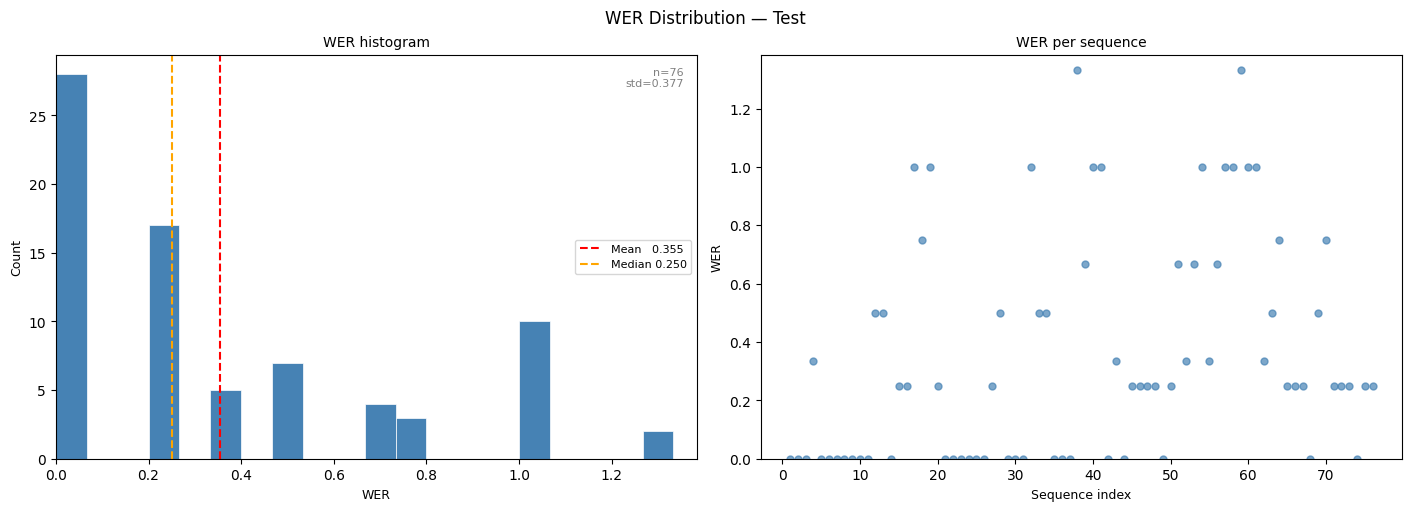

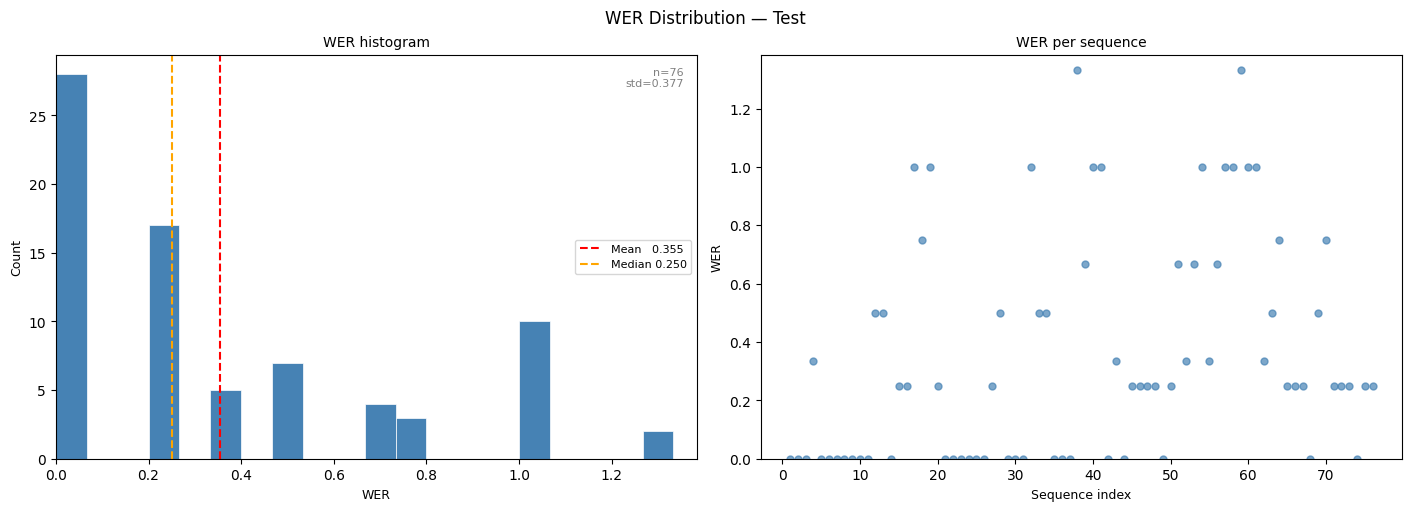

In [ ]:
# ============================================================
# Plot 3 — WER distribution for the test split
# ============================================================
plot_wer_distribution(test_df, split_name="Test", top_n_worst=5)